# SHOTS Table
## All shots taken in one of the Top5 leagues over the specified time window (2014-2020)
---
## Uso de DataFrames

Los DataFrames son el tipo de objetos principales de Pandas. Son una representación de una tabla. Se pueden acceder a las filas y las columnas. Cada una de las columnas se considera una Serie

## Proceso para analizar un archivo

1. Cargar el archivo en un Data Frame
2. Hacer una revisión de los tipos de datos del archivo.
3. Revisar si existen datos nulos y datos duplicados en el archivo
4. Eliminar inconsistencias
5. Llevar a cabo el ánalisis apoyados de gráficas

## Tomar en consideración:
- Elegir un archivo que contenga datos númerico y no númericos
- Crear un archivo como este que contenga la descripción de su proceso de análisis
- Preparar una presentación para el día de entrega (viernes)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('shots_table.csv')
# df.head() -> Primeras 5 filas de su archivo
# df.head(n) -> Primeras n filas de su archivo
df.head()

,gameID,shooterID,assisterID,minute,situation,lastAction,shotType,shotResult,xGoal,positionX,positionY
0,81,554,NaN,27,DirectFreekick,Standard,LeftFoot,BlockedShot,0.104347,0.794,0.421
1,81,555,631.0,27,SetPiece,Pass,RightFoot,BlockedShot,0.064342,0.860,0.627
2,81,554,629.0,35,OpenPlay,Pass,LeftFoot,BlockedShot,0.057157,0.843,0.333
3,81,554,NaN,35,OpenPlay,Tackle,LeftFoot,MissedShots,0.092141,0.848,0.533
4,81,555,654.0,40,OpenPlay,BallRecovery,RightFoot,BlockedShot,0.035742,0.812,0.707


In [4]:
df.tail()

,gameID,shooterID,assisterID,minute,situation,lastAction,shotType,shotResult,xGoal,positionX,positionY
324538,16135,6615,8651.0,19,SetPiece,Aerial,Head,MissedShots,0.039172,0.899,0.511
324539,16135,6615,8651.0,54,SetPiece,Cross,LeftFoot,Goal,0.372809,0.902,0.482
324540,16135,3464,NaN,70,OpenPlay,NaN,LeftFoot,MissedShots,0.009242,0.738,0.774
324541,16135,8651,4882.0,72,OpenPlay,Cross,Head,BlockedShot,0.045374,0.882,0.543
324542,16135,8651,4882.0,85,OpenPlay,Pass,RightFoot,MissedShots,0.013121,0.653,0.359


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324543 entries, 0 to 324542
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   gameID      324543 non-null  int64  
 1   shooterID   324543 non-null  int64  
 2   assisterID  240199 non-null  float64
 3   minute      324543 non-null  int64  
 4   situation   324543 non-null  object 
 5   lastAction  287647 non-null  object 
 6   shotType    324543 non-null  object 
 7   shotResult  324543 non-null  object 
 8   xGoal       324543 non-null  float64
 9   positionX   324543 non-null  float64
 10  positionY   324543 non-null  float64
dtypes: float64(4), int64(3), object(4)
memory usage: 27.2+ MB


In [62]:
df.describe()

,gameID,shooterID,assisterID,minute,xGoal,positionX,positionY
count,324543.000000,324543.000000,240199.000000,324543.000000,324543.000000,324543.000000,324543.000000
mean,7832.533381,2691.279211,2685.515439,48.573588,0.108760,0.843968,0.504613
std,4729.926230,2272.984642,2286.099575,26.578582,0.160913,0.090014,0.129372
min,81.000000,2.000000,1.000000,0.000000,0.000000,0.003000,0.000000
25%,3808.000000,845.000000,835.000000,26.000000,0.024060,0.781000,0.414000
50%,7966.000000,2080.000000,2094.000000,49.000000,0.049969,0.863000,0.501000
75%,11954.000000,3785.000000,3744.000000,71.000000,0.094484,0.909000,0.597000
max,16135.000000,9567.000000,9567.000000,104.000000,0.979887,0.999000,0.997000


In [7]:
df.columns

Index(['gameID', 'shooterID', 'assisterID', 'minute', 'situation',
       'lastAction', 'shotType', 'shotResult', 'xGoal', 'positionX',
       'positionY'],
      dtype='object')

In [10]:
# Medidas de tendencia central
print(f'Promedio:{df['xGoal'].mean()}')
print(f'Mediana:{df['xGoal'].median()}')
print(f'Moda:{df['xGoal'].mode()}')
# Medidas de dispersión
print(f'Desviación estándar:{df['xGoal'].std()}')
print(f'Varianza:{df['xGoal'].var()}')
# Medidas de posición
print(f"Mínimo:{df['xGoal'].min()}")
print(f'Q1:{df['xGoal'].quantile(0.25)}')
print(f'Q2:{df['xGoal'].quantile(0.50)}')
print(f'Q3:{df['xGoal'].quantile(0.75)}')
print(f'Máximo:{df['xGoal'].max()}')

Promedio:0.10876032890816117
Mediana:0.0499694310128689
Moda:0    0.0
Name: xGoal, dtype: float64
Desviación estándar:0.16091325696287578
Varianza:0.02589307626640049
Mínimo:0.0
Q1:0.024060424417257302
Q2:0.0499694310128689
Q3:0.09448416903615
Máximo:0.979886770248413


<Axes: >

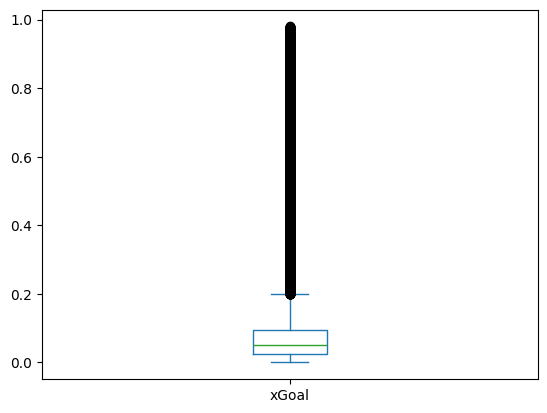

In [11]:
# Cajas y bigotes (box & whiskers) -> Gráficas de cajas (boxplots)
df['xGoal'].plot.box()

In [12]:
df["xGoal"].dtype

dtype('float64')

In [13]:
columnas_numericas = []
columnas_no_numericas = []
for col in df.columns:
    if df[col].dtype == "object":
        columnas_no_numericas.append(col)
    else:
        columnas_numericas.append(col)
print(f'Columnas numéricas: {columnas_numericas}')
print(f'Columnas no numéricas: {columnas_no_numericas}')

Columnas numéricas: ['gameID', 'shooterID', 'assisterID', 'minute', 'xGoal', 'positionX', 'positionY']
Columnas no numéricas: ['situation', 'lastAction', 'shotType', 'shotResult']


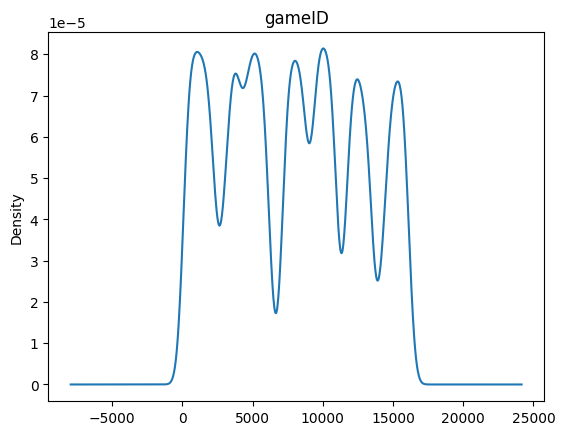

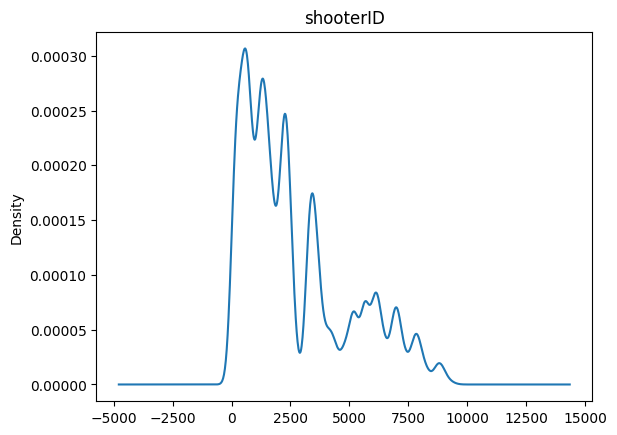

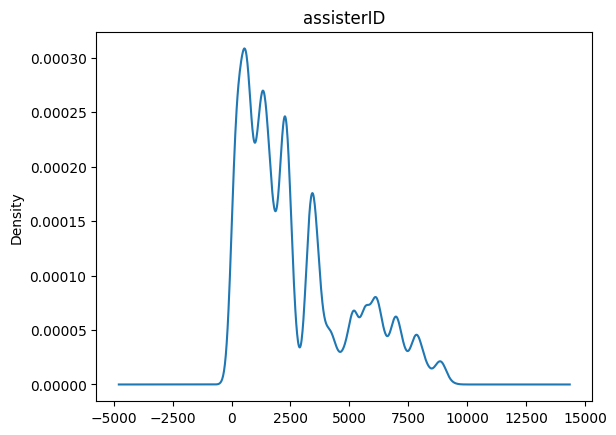

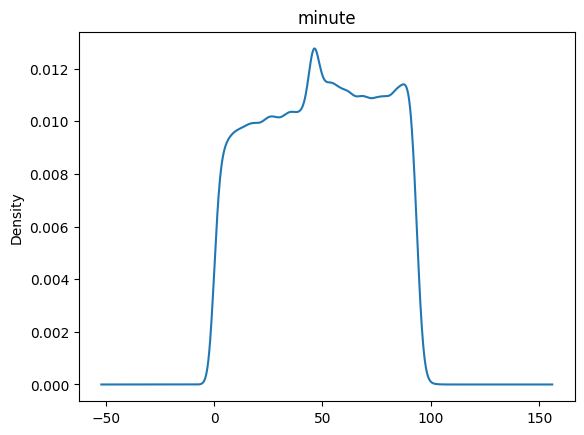

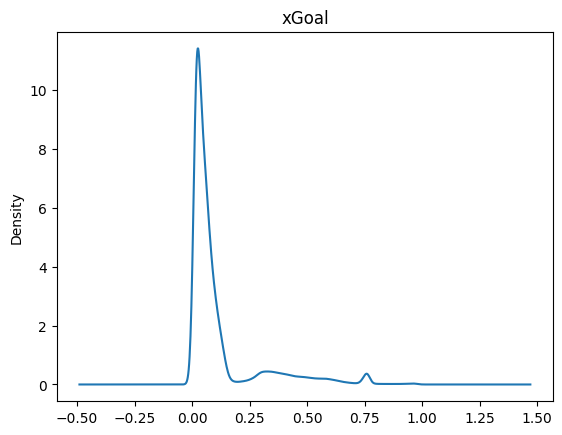

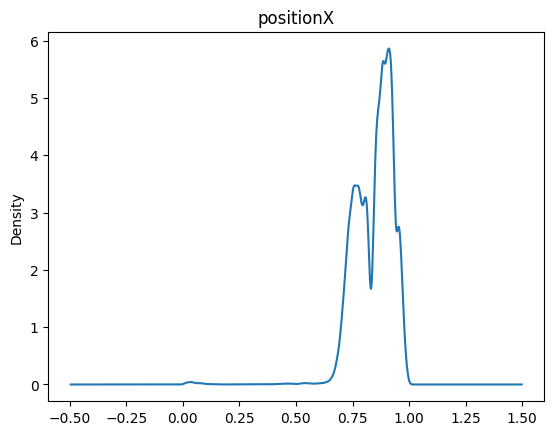

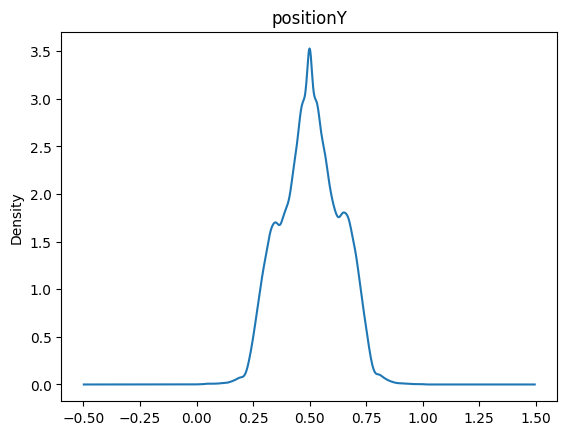

In [15]:
for col in columnas_numericas:
    df[col].plot.kde(title=col)
    plt.show()

In [16]:
df.head()

,gameID,shooterID,assisterID,minute,situation,lastAction,shotType,shotResult,xGoal,positionX,positionY
0,81,554,NaN,27,DirectFreekick,Standard,LeftFoot,BlockedShot,0.104347,0.794,0.421
1,81,555,631.0,27,SetPiece,Pass,RightFoot,BlockedShot,0.064342,0.860,0.627
2,81,554,629.0,35,OpenPlay,Pass,LeftFoot,BlockedShot,0.057157,0.843,0.333
3,81,554,NaN,35,OpenPlay,Tackle,LeftFoot,MissedShots,0.092141,0.848,0.533
4,81,555,654.0,40,OpenPlay,BallRecovery,RightFoot,BlockedShot,0.035742,0.812,0.707


In [20]:
df['minute'].value_counts(bins=10)

(41.6, 52.0]      42771
(72.8, 83.2]      39018
(52.0, 62.4]      36864
(20.8, 31.2]      35987
(83.2, 93.6]      35736
(62.4, 72.8]      35471
(31.2, 41.6]      33582
(10.4, 20.8]      32034
(-0.105, 10.4]    30819
(93.6, 104.0]      2261
Name: count, dtype: int64

<Axes: title={'center': 'minute'}, ylabel='Frequency'>

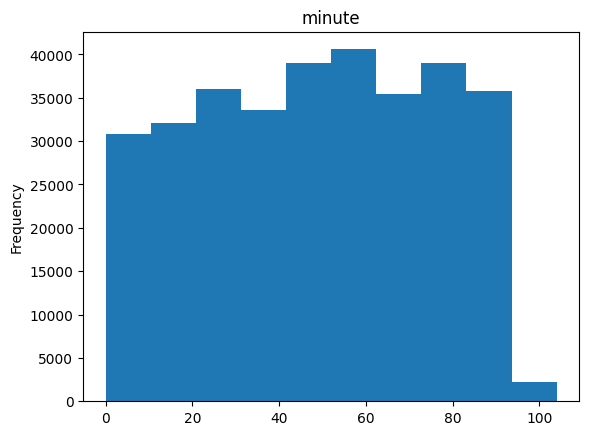

In [21]:
df['minute'].plot.hist(bins=10, title='minute')

In [22]:
df['situation'].unique()

array(['DirectFreekick', 'SetPiece', 'OpenPlay', 'FromCorner', 'Penalty'],
      dtype=object)

<Axes: title={'center': 'Goles a partir del minuto 80'}, ylabel='count'>

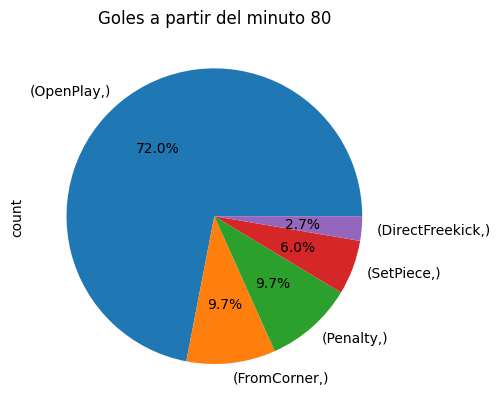

In [39]:
df.loc[(df['shotResult'] == 'Goal') & (df['minute'] >=80), ["situation"]].value_counts().plot.pie(autopct='%.1f%%',title='Goles a partir del minuto 80')

<Axes: title={'center': 'Tiros de esquina a partir del minuto 80'}, ylabel='count'>

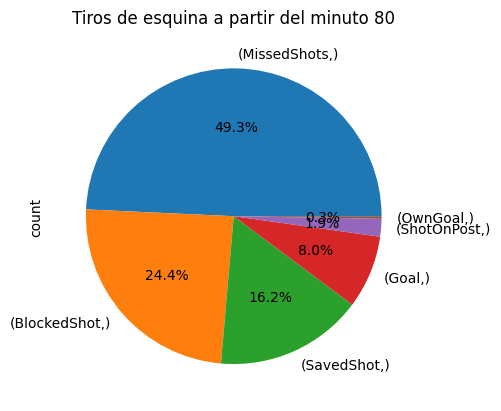

In [40]:
df.loc[(df['situation'] == 'FromCorner') & (df['minute'] >=80), ["shotResult"]].value_counts().plot.pie(autopct='%.1f%%',title='Tiros de esquina a partir del minuto 80')

<Axes: title={'center': 'Penales a partir del minuto 80'}, ylabel='count'>

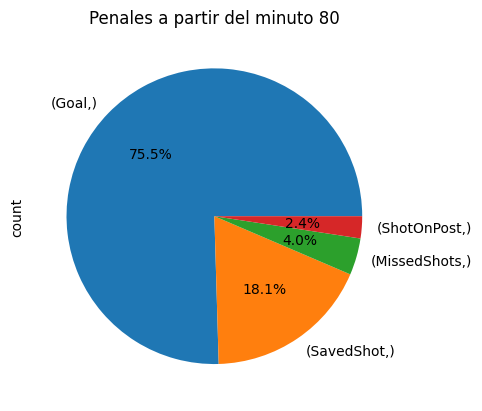

In [41]:
df.loc[(df['situation'] == 'Penalty') & (df['minute'] >=80), ["shotResult"]].value_counts().plot.pie(autopct='%.1f%%',title='Penales a partir del minuto 80')

<Axes: title={'center': 'Jugadas libres a partir del minuto 80'}, ylabel='count'>

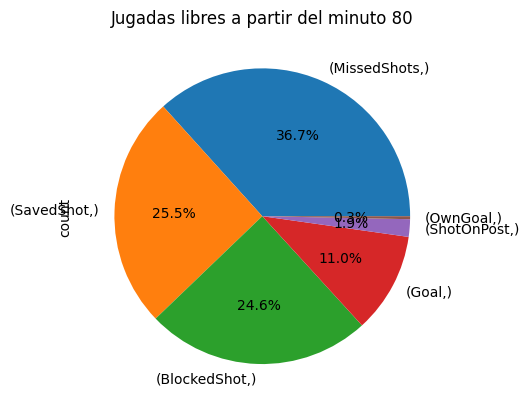

In [42]:
df.loc[(df['situation'] == 'OpenPlay') & (df['minute'] >=80), ["shotResult"]].value_counts().plot.pie(autopct='%.1f%%',title='Jugadas libres a partir del minuto 80')

<Axes: title={'center': 'Jugadas prefabricadas a partir del minuto 80'}, ylabel='count'>

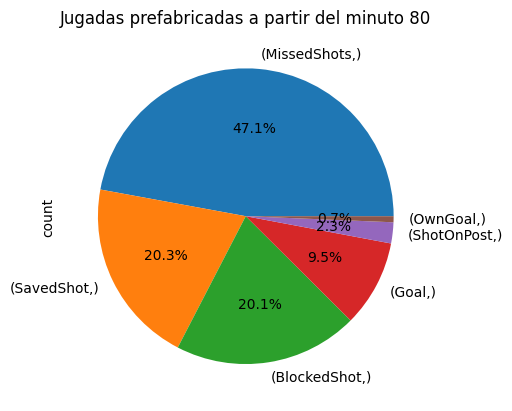

In [43]:
df.loc[(df['situation'] == 'SetPiece') & (df['minute'] >=80), ["shotResult"]].value_counts().plot.pie(autopct='%.1f%%',title='Jugadas prefabricadas a partir del minuto 80')

<Axes: title={'center': 'Tiro Libre Directo a partir del minuto 80'}, ylabel='count'>

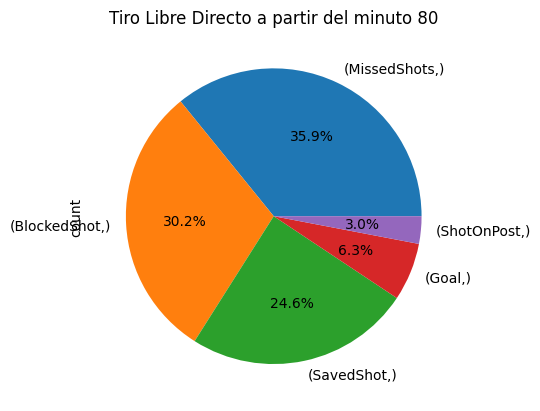

In [44]:
df.loc[(df['situation'] == 'DirectFreekick') & (df['minute'] >=80), ["shotResult"]].value_counts().plot.pie(autopct='%.1f%%',title='Tiro Libre Directo a partir del minuto 80')

<Axes: title={'center': 'Situaciones previas que terminan en gol a partir del minuto 80'}, ylabel='count'>

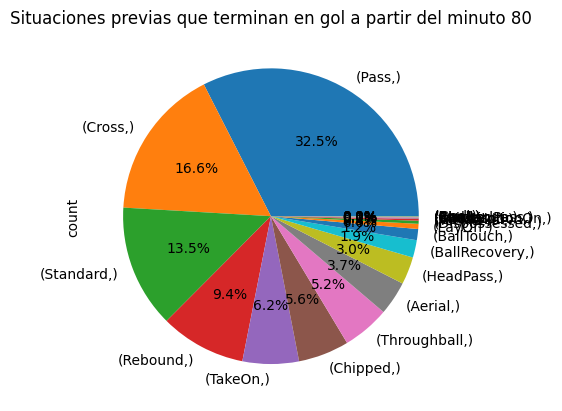

In [48]:
df.loc[(df['minute'] >=80) & (df["shotResult"]=="Goal"), ['lastAction']].value_counts().plot.pie(autopct='%.1f%%',title='Situaciones previas que terminan en gol a partir del minuto 80')

<Axes: title={'center': 'Promedio de xGoal por tipo de situación a partir del minuto 80'}, xlabel='situation'>

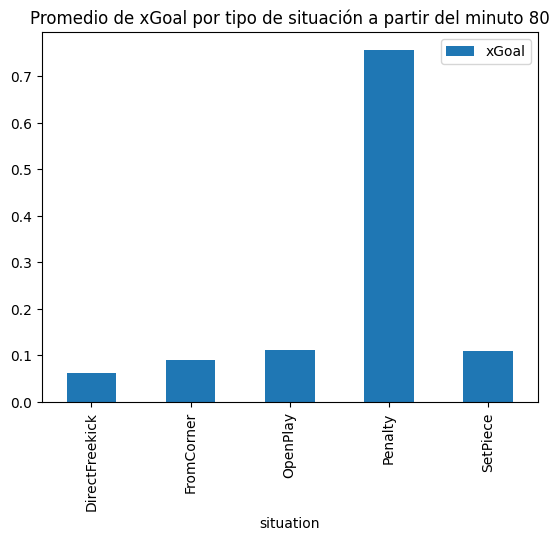

In [49]:
# Promedio de xGoal por tipo de situación a partir del minuto 80.
df.loc[df['minute'] >=80].groupby('situation')['xGoal'].mean().reset_index().plot.bar(x='situation', y='xGoal', title='Promedio de xGoal por tipo de situación a partir del minuto 80')

<Axes: title={'center': 'Minutos vs xGoal para goles que se anotaron'}, xlabel='minute', ylabel='xGoal'>

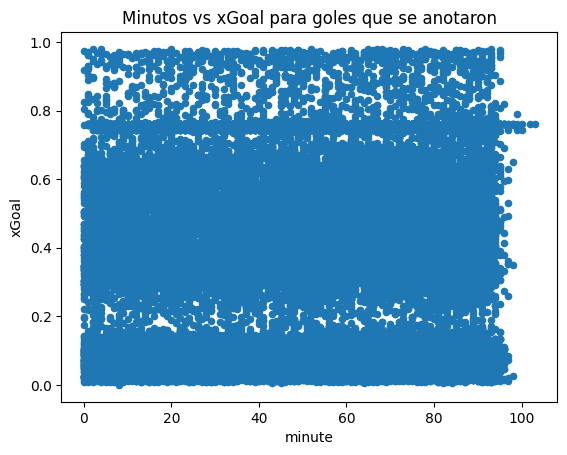

In [54]:
# Grafica de minutos (a partir del minuto 80) vs xGoal para tiros que resultaron en gol.
df.loc[(df["shotResult"]=="Goal")].plot.scatter(x='minute', y='xGoal', title='Minutos vs xGoal para goles que se anotaron')